pip install sparsecca

# 0428 version 
## updated from 0404sparsecca
## from all microbes dataset: species_speciman

In [1]:
import sparsecca
print(dir(sparsecca))  # Should show `_pmd`, `_cca_pmd`, etc.

['__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', '_cca_ipls', '_cca_pmd', '_multicca_lp', '_multicca_pmd', '_multicca_pmd_permute', '_pmd', '_utils_pmd', 'binary_search', 'cca_ipls', 'cca_pmd', 'l2n', 'lp_pmd', 'multicca_permute', 'multicca_pmd', 'pmd', 'scale', 'soft']


In [2]:
import numpy as np
import pandas as pd
from sparsecca import pmd  # Import xx function from sparsecca
from scipy.stats import zscore

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import os
os.environ["OMP_NUM_THREADS"] = "16"  # 限制最多使用 16 核

## load Data

In [5]:
groups = {
    "ileum_high": ("x565.ileum.high.csv", "y565.ileum.high.csv"),
    "ileum_low": ("x565.ileum.low.csv", "y565.ileum.low.csv"),
    "colon_high": ("x565.left.colon.high.csv", "y565.left.colon.high.csv"),
    "colon_low": ("x565.left.colon.low.csv", "y565.left.colon.low.csv"),
}

In [6]:
def run_sparsecca(x_file, y_file, group_name, penaltyu=0.95, penaltyv=0.9, K=2):
    # Load data
    df_x = pd.read_csv(x_file, delimiter=",").drop(columns=["Unnamed: 0"])
    df_y = pd.read_csv(y_file, delimiter=",").drop(columns=["Unnamed: 0"])
    
    df_x = df_x.select_dtypes(include=np.number)
    df_y = df_y.select_dtypes(include=np.number)
    # Standardize
    X = zscore(df_x.to_numpy())
    Y = zscore(df_y.to_numpy())
    #X = df_x.apply(zscore).to_numpy()  
    #Y = df_y.apply(zscore).to_numpy()  

    # Run Sparse CCA via PMD
    U, V, D = pmd(X.T @ Y, K=K, penaltyu=penaltyu, penaltyv=penaltyv, standardize=False)

    # Canonical correlation
    corrs = [np.corrcoef(np.dot(U[:, k], X.T), np.dot(V[:, k], Y.T))[0, 1] for k in range(K)]

    # Get important genes and microbes (nonzero loadings)
    gene_names = df_x.columns
    microbe_names = df_y.columns

    selected_genes = gene_names[np.abs(U[:, 0]) > 0.01]
    selected_microbes = microbe_names[np.abs(V[:, 0]) > 0.01]

    # Save results
    return {
        "group": group_name,
        "X": X,
        "Y": Y,
        "U": U,
        "V": V,
        "corrs": corrs,
        "genes": selected_genes.tolist(),
        "microbes": selected_microbes.tolist(),
        "X_columns": gene_names.tolist(),
        "Y_columns": microbe_names.tolist(),
    }

# Run Sparse CCA

# Extract results

In [7]:
results = []

for name, (x_file, y_file) in groups.items():
    print(f"Running Sparse CCA for {name}...")
    res = run_sparsecca(x_file, y_file, group_name=name)
    results.append(res)

Running Sparse CCA for ileum_high...
Running Sparse CCA for ileum_low...
Running Sparse CCA for colon_high...
Running Sparse CCA for colon_low...


# updated on 7/16 , then want to get sig genes & microbes result for 1st canonical correlate, and then do comparisons bwt high vs low

In [8]:
# Step 1: collect gene/microbe sets
group_features = {res["group"]: {"genes": set(res["genes"]), "microbes": set(res["microbes"])} for res in results}

# Step 2: site-specific comparisons
ileum_gene_diff = group_features["ileum_high"]["genes"] ^ group_features["ileum_low"]["genes"]
ileum_microbe_diff = group_features["ileum_high"]["microbes"] ^ group_features["ileum_low"]["microbes"]

colon_gene_diff = group_features["colon_high"]["genes"] ^ group_features["colon_low"]["genes"]
colon_microbe_diff = group_features["colon_high"]["microbes"] ^ group_features["colon_low"]["microbes"]

In [9]:
print(group_features["ileum_high"])

{'genes': {'ENSG00000198826', 'ENSG00000155100', 'ENSG00000132286', 'ENSG00000110002', 'ENSG00000240849', 'ENSG00000139437', 'ENSG00000101331', 'ENSG00000133317', 'ENSG00000158006', 'ENSG00000163605', 'ENSG00000111481', 'ENSG00000157554', 'ENSG00000162670', 'ENSG00000249236', 'ENSG00000118946', 'ENSG00000128045', 'ENSG00000105058', 'ENSG00000152939', 'ENSG00000181001', 'ENSG00000141738', 'ENSG00000113739', 'ENSG00000109944', 'ENSG00000171992', 'ENSG00000172765', 'ENSG00000271427', 'ENSG00000107854', 'ENSG00000053900', 'ENSG00000125304', 'ENSG00000260342', 'ENSG00000265690', 'ENSG00000070748', 'ENSG00000138722', 'ENSG00000242568', 'ENSG00000127588', 'ENSG00000132763', 'ENSG00000183578', 'ENSG00000182472', 'ENSG00000022556', 'ENSG00000187244', 'ENSG00000135547', 'ENSG00000100124', 'ENSG00000128340', 'ENSG00000132746', 'ENSG00000204764', 'ENSG00000089505', 'ENSG00000196230', 'ENSG00000171450', 'ENSG00000144655', 'ENSG00000163428', 'ENSG00000229236', 'ENSG00000108883', 'ENSG00000144843', '

In [10]:
def extract_pair_info(res, component=0, weight_thresh=0.01):
    U = res["U"][:, component]
    V = res["V"][:, component]
    genes = np.array(res["X_columns"])
    microbes = np.array(res["Y_columns"])

    selected_gene_idx = np.where(np.abs(U) > weight_thresh)[0]
    selected_microbe_idx = np.where(np.abs(V) > weight_thresh)[0]

    pairs_info = []
    for gi in selected_gene_idx:
        for mi in selected_microbe_idx:
            pair_score = abs(U[gi] * V[mi])
            pairs_info.append({
                "Gene": genes[gi],
                "Microbe": microbes[mi],
                "U_weight": U[gi],
                "V_weight": V[mi],
                "PairScore": pair_score
            })
    return pd.DataFrame(pairs_info)


# 构建 group dict
results_dict = {res["group"]: res for res in results}

# 分别提取所有 pair info
ileum_high_df = extract_pair_info(results_dict["ileum_high"])
ileum_low_df  = extract_pair_info(results_dict["ileum_low"])
colon_high_df = extract_pair_info(results_dict["colon_high"])
colon_low_df  = extract_pair_info(results_dict["colon_low"])

## 7/26 updated function (add cross validation)

In [11]:
def extract_pair_info_with_cv(res, component=0, candidate_thresholds=[0.011, 0.012, 0.019, 0.02, 0.022, 0.025, 0.03]):
    U = res["U"][:, component]
    V = res["V"][:, component]
    genes = np.array(res["X_columns"])
    microbes = np.array(res["Y_columns"])

    best_thresh = None
    best_corr = -1
    best_df = None

    # Canonical variables
    X_proj = res["X"] @ U
    Y_proj = res["Y"] @ V
    canonical_corr = np.corrcoef(X_proj, Y_proj)[0, 1]

    for thresh in candidate_thresholds:
        selected_gene_idx = np.where(np.abs(U) > thresh)[0]
        selected_microbe_idx = np.where(np.abs(V) > thresh)[0]

        if len(selected_gene_idx) == 0 or len(selected_microbe_idx) == 0:
            continue  # skip this threshold

        pairs_info = []
        for gi in selected_gene_idx:
            for mi in selected_microbe_idx:
                pair_score = abs(U[gi] * V[mi])
                pairs_info.append({
                    "Gene": genes[gi],
                    "Microbe": microbes[mi],
                    "U_weight": U[gi],
                    "V_weight": V[mi],
                    "PairScore": pair_score
                })

        df = pd.DataFrame(pairs_info)
        score = df["PairScore"].median()

        if score > best_corr:
            best_corr = score
            best_thresh = thresh
            best_df = df

    print(f"Best threshold selected: {best_thresh}, score: {round(best_corr, 4)}")
    return best_df

In [12]:
# 构建 group dict
results_dict = {res["group"]: res for res in results}

# 分别提取所有 pair info
ileum_high_df = extract_pair_info_with_cv(results_dict["ileum_high"])
ileum_low_df  = extract_pair_info_with_cv(results_dict["ileum_low"])
colon_high_df = extract_pair_info_with_cv(results_dict["colon_high"])
colon_low_df  = extract_pair_info_with_cv(results_dict["colon_low"])

Best threshold selected: 0.011, score: 0.0005
Best threshold selected: 0.025, score: 0.0014
Best threshold selected: 0.019, score: 0.0009
Best threshold selected: 0.019, score: 0.0011


阈值不同会导致选入的pair数量差异，我们关心在最强的canonical相关性的情况下哪些pair是group-specific

In [13]:
# 添加唯一 pair key for diff comparison
def make_key(df):
    return df["Gene"] + "|" + df["Microbe"]

ileum_high_df["pair_key"] = make_key(ileum_high_df)
ileum_low_df["pair_key"]  = make_key(ileum_low_df)
colon_high_df["pair_key"] = make_key(colon_high_df)
colon_low_df["pair_key"]  = make_key(colon_low_df)

# 找出 non-overlapping pair_key
ileum_diff_keys = set(ileum_high_df["pair_key"]) - set(ileum_low_df["pair_key"])
colon_diff_keys = set(colon_high_df["pair_key"]) - set(colon_low_df["pair_key"])

# 提取 diff rows
ileum_diff_df = pd.concat([
    ileum_high_df[ileum_high_df["pair_key"].isin(ileum_diff_keys)],
    ileum_low_df[ileum_low_df["pair_key"].isin(ileum_diff_keys)]
])

colon_diff_df = pd.concat([
    colon_high_df[colon_high_df["pair_key"].isin(colon_diff_keys)],
    colon_low_df[colon_low_df["pair_key"].isin(colon_diff_keys)]
])

In [14]:
# 去掉临时列
ileum_diff_df = ileum_diff_df.drop(columns=["pair_key"])
colon_diff_df = colon_diff_df.drop(columns=["pair_key"])

# 按 pair score 排序（可选）
ileum_diff_df = ileum_diff_df.sort_values(by="PairScore", ascending=False)
colon_diff_df = colon_diff_df.sort_values(by="PairScore", ascending=False)

print("Ileum diff pair count:", len(ileum_diff_df))
print("Colon diff pair count:", len(colon_diff_df))


Ileum diff pair count: 371305
Colon diff pair count: 16465


In [15]:
## 重复
print(ileum_diff_df.head(10))
print(colon_diff_df.head(10))

                   Gene                              Microbe  U_weight  \
285958  ENSG00000188483  Lachnospiraceae_bacterium_6_1_63FAA  0.011439   
320487  ENSG00000213977  Lachnospiraceae_bacterium_6_1_63FAA  0.011439   
207913  ENSG00000164024  Lachnospiraceae_bacterium_6_1_63FAA  0.011436   
147842  ENSG00000142208  Lachnospiraceae_bacterium_6_1_63FAA  0.011434   
291634  ENSG00000189308  Lachnospiraceae_bacterium_6_1_63FAA  0.011434   
252375  ENSG00000177311  Lachnospiraceae_bacterium_6_1_63FAA  0.011433   
255686  ENSG00000178409  Lachnospiraceae_bacterium_6_1_63FAA  0.011433   
155410  ENSG00000144840  Lachnospiraceae_bacterium_6_1_63FAA  0.011432   
113786  ENSG00000131149  Lachnospiraceae_bacterium_6_1_63FAA  0.011432   
32430   ENSG00000078618  Lachnospiraceae_bacterium_6_1_63FAA  0.011432   

        V_weight  PairScore  
285958 -0.065356   0.000748  
320487 -0.065356   0.000748  
207913 -0.065356   0.000747  
147842 -0.065356   0.000747  
291634 -0.065356   0.000747  
25237

In [16]:
# 保存结果
ileum_diff_df.to_csv("ileum_diff_pairs_scored.csv", index=False)
colon_diff_df.to_csv("colon_diff_pairs_scored.csv", index=False)

In [17]:
def get_top_nonredundant_pairs(df, top_n=100):
    selected_pairs = []
    used_genes = set()
    used_microbes = set()

    for _, row in df.sort_values("PairScore", ascending=False).iterrows():
        g, m = row["Gene"], row["Microbe"]
        if g not in used_genes and m not in used_microbes:
            selected_pairs.append(row)
            used_genes.add(g)
            used_microbes.add(m)
        
    return pd.DataFrame(selected_pairs)


In [18]:
ileum_diff = get_top_nonredundant_pairs(ileum_diff_df)
print(len(ileum_diff))  # 293 to 473

473


In [19]:
colon_diff = get_top_nonredundant_pairs(colon_diff_df)
print(len(colon_diff))  # 9 to 37

37


In [20]:
ileum_diff.to_csv("ileum_diff_pairs.csv", index=False)
colon_diff.to_csv("colon_diff_pairs.csv", index=False)

In [20]:
# 只看 top 10 对
top_ileum_pairs = ileum_diff_df.sort_values(by="PairScore", ascending=False).head(10)
top_colon_pairs = colon_diff_df.sort_values(by="PairScore", ascending=False).head(10)
print(top_ileum_pairs)

                  Gene                                 Microbe  U_weight  \
99540  ENSG00000121318                       Selenomonas_noxia  0.023796   
99368  ENSG00000121318                       Facklamia_hominis  0.023796   
99576  ENSG00000121318                     Tropheryma_whipplei  0.023796   
99461  ENSG00000121318                     Mobiluncus_curtisii  0.023796   
99345  ENSG00000121318                      Enterococcus_asini  0.023796   
99264  ENSG00000121318              Butyricimonas_synergistica  0.023796   
99246  ENSG00000121318  Bacteroidetes_bacterium_oral_taxon_272  0.023796   
99425  ENSG00000121318                  Lactobacillus_jensenii  0.023796   
99446  ENSG00000121318                       Leuconostoc_inhae  0.023796   
99340  ENSG00000121318                  Eggerthia_catenaformis  0.023796   

       V_weight  PairScore  
99540 -0.062117   0.001478  
99368 -0.062117   0.001478  
99576 -0.062117   0.001478  
99461 -0.062117   0.001478  
99345 -0.062117   

def get_feature_pairs(res, component=0, weight_thresh=0.02):
    U = res["U"][:, component]
    V = res["V"][:, component]
    genes = np.array(res["X_columns"])
    microbes = np.array(res["Y_columns"])

    selected_gene_idx = np.where(np.abs(U) > weight_thresh)[0]
    selected_microbe_idx = np.where(np.abs(V) > weight_thresh)[0]

    gene_names = genes[selected_gene_idx]
    microbe_names = microbes[selected_microbe_idx]

    # Cartesian product of gene x microbe
    pairs = [(g, m) for g in gene_names for m in microbe_names]
    return set(pairs)


In [35]:
print(f"Number of ileum_diff_pairs: {len(ileum_diff_pairs)}")


# 转成 list 并打印前10项
for pair in list(ileum_diff_pairs)[:10]:
    print(pair)



Number of ileum_diff_pairs: 13135
('ENSG00000101405', 'Shigella_flexneri')
('ENSG00000141452', 'Bacteroides_coprophilus')
('ENSG00000133027', 'Lactobacillus_johnsonii')
('ENSG00000204147', 'Selenomonas_noxia')
('ENSG00000197905', 'Streptococcus_oligofermentans')
('ENSG00000105996', 'Corynebacterium_amycolatum')
('ENSG00000185813', 'Clostridium_sp_L2_50')
('ENSG00000198873', 'Streptococcus_infantis')
('ENSG00000253309', 'Coprobacillus_sp_29_1')
('ENSG00000130988', 'Neisseria_subflava')


In [8]:
for res in results:
    print(f"{res['group']}: ")
    corrcoef_1 = res["corrs"][0]  # Component 1
    corrcoef_2 = res["corrs"][1]  # Component 2
    print(f"component1: ", corrcoef_1)
    #print(f"component2: ", corrcoef_2)

ileum_high: 
component1:  0.8676958332819881
ileum_low: 
component1:  0.4941612389934617
colon_high: 
component1:  0.7923334361574073
colon_low: 
component1:  0.4068392436301709


In [9]:
def get_top_features(result, top_n_genes=20, top_n_microbes=10):
    U = result["U"][:, 0]  # 第一个 canonical component
    V = result["V"][:, 0]
    
    gene_names = result["genes"]  # 你保存的筛选过的基因名
    microbe_names = result["microbes"]

    # 全部基因名称（对应 U 的位置）
    full_gene_names = result["X_columns"] if "X_columns" in result else gene_names
    full_microbe_names = result["Y_columns"] if "Y_columns" in result else microbe_names

    # 创建 λ 映射
    gene_weights = dict(zip(full_gene_names, U))
    microbe_weights = dict(zip(full_microbe_names, V))

    # 只保留 selected genes/microbes 中的 top N
    top_genes = sorted([(g, gene_weights[g]) for g in gene_names], key=lambda x: -abs(x[1]))[:top_n_genes]
    top_microbes = sorted([(m, microbe_weights[m]) for m in microbe_names], key=lambda x: -abs(x[1]))[:top_n_microbes]

    return top_genes, top_microbes


def plot_heatmap(result, top_n_genes=20, top_n_microbes=10):
    U = result["U"][:, 0]
    V = result["V"][:, 0]
    gene_names = result["X_columns"] if "X_columns" in result else result["genes"]
    microbe_names = result["Y_columns"] if "Y_columns" in result else result["microbes"]

    # 获取排序索引
    top_gene_idx = np.argsort(np.abs(U))[::-1][:top_n_genes]
    top_microbe_idx = np.argsort(np.abs(V))[::-1][:top_n_microbes]

    interaction_matrix = np.outer(U, V)[top_gene_idx, :][:, top_microbe_idx]

    # 设置标签
    gene_labels = np.array(gene_names)[top_gene_idx]
    microbe_labels = np.array(microbe_names)[top_microbe_idx]

    # 画热图
    plt.figure(figsize=(10, 6))
    #sns.heatmap(interaction_matrix, xticklabels=microbe_labels, yticklabels=gene_labels, cmap="coolwarm", center=0, annot=False, fmt=".2f")
    sns.heatmap(interaction_matrix,
            xticklabels=microbe_labels,
            yticklabels=gene_labels,
            cmap="coolwarm", center=0,
            vmin=-0.005, vmax=0.005)  # set consistent scale
    plt.title(f"Gene–Microbe Interaction Heatmap - {result['group']}")
    plt.xlabel("Microbes")
    plt.ylabel("Genes")
    plt.tight_layout()
    plt.show()

==== ileum_high ====
Top Genes: [('ENSG00000213977', 0.012483365863887222), ('ENSG00000131149', 0.012475376121142804), ('ENSG00000146826', 0.01246560995453865), ('ENSG00000205336', 0.012462392067162879), ('ENSG00000196642', 0.012448121923753531), ('ENSG00000133265', 0.012446716579048842), ('ENSG00000188483', 0.012444712079047566), ('ENSG00000013288', 0.012439737216551247), ('ENSG00000169181', 0.012435784279132714), ('ENSG00000167323', 0.012432397813255372), ('ENSG00000151067', 0.012431668166236474), ('ENSG00000204525', 0.012428321278136147), ('ENSG00000100092', 0.012427388134984887), ('ENSG00000171159', 0.012424848973553735), ('ENSG00000108639', 0.012417524051401702), ('ENSG00000175727', 0.012412662689203451), ('ENSG00000048828', 0.012407341323937695), ('ENSG00000161179', 0.012406491060346582), ('ENSG00000147799', 0.012405332056089917), ('ENSG00000149925', 0.012404120113125442)]
Top Microbes: [('Lachnospiraceae_bacterium_2_1_58FAA', -0.056732822910916136), ('Eubacterium_brachy', 0.0556

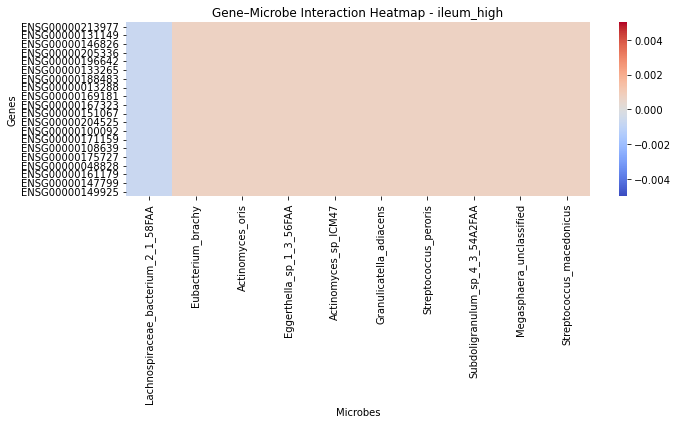

==== ileum_low ====
Top Genes: [('ENSG00000121318', 0.023795657640729665), ('ENSG00000182156', -0.02309570892356201), ('ENSG00000138075', -0.023079474176363253), ('ENSG00000175520', 0.022967327934334224), ('ENSG00000129159', 0.022869095457016323), ('ENSG00000137434', -0.022753129176511157), ('ENSG00000143921', -0.02259906837364742), ('ENSG00000198873', -0.02230660370702944), ('ENSG00000173531', -0.022191737170484248), ('ENSG00000139629', -0.021894801301108536), ('ENSG00000106804', -0.021883066343997355), ('ENSG00000008405', -0.02172460994864206), ('ENSG00000130830', -0.021530976640500358), ('ENSG00000198805', -0.021431956873455702), ('ENSG00000137968', 0.021410829545245473), ('ENSG00000121073', -0.021399391519428188), ('ENSG00000188611', -0.021372652497286926), ('ENSG00000253309', -0.021349959036695884), ('ENSG00000062282', -0.021135842324108728), ('ENSG00000211445', -0.0211197989874143)]
Top Microbes: [('Selenomonas_noxia', -0.06211670451018137), ('Facklamia_hominis', -0.0621167045101

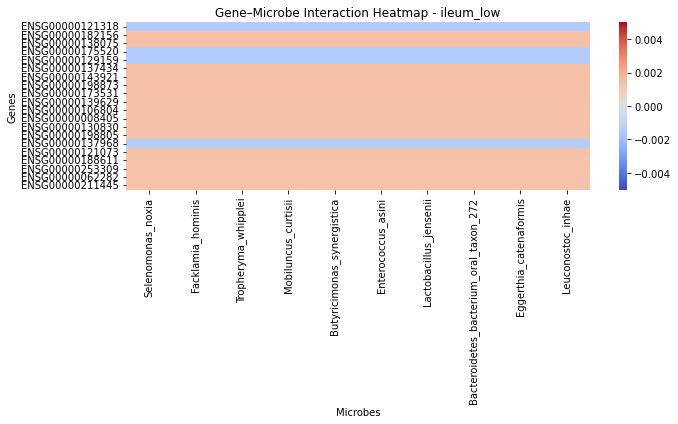

==== colon_high ====
Top Genes: [('ENSG00000170290', -0.02311747952608759), ('ENSG00000230174', -0.0227859981151234), ('ENSG00000233922', -0.0227859981151234), ('ENSG00000254288', -0.0227859981151234), ('ENSG00000064205', -0.02272984996805182), ('ENSG00000272512', 0.022531614310253797), ('ENSG00000263884', -0.022454214270580784), ('ENSG00000086717', -0.022122699846483806), ('ENSG00000245526', -0.022008725231186393), ('ENSG00000154678', 0.021789207081004104), ('ENSG00000162374', -0.021648167054572932), ('ENSG00000214146', -0.02159468722832791), ('ENSG00000258838', -0.021563798101348883), ('ENSG00000188817', -0.021554326963389877), ('ENSG00000213240', -0.021487575311406198), ('ENSG00000225206', -0.021403369692291417), ('ENSG00000273198', -0.021398454175132), ('ENSG00000212855', -0.021337810767670388), ('ENSG00000237638', -0.021317407881737076), ('ENSG00000272255', -0.021264054466402872)]
Top Microbes: [('Ruminococcus_obeum', -0.059695514971818214), ('Bifidobacterium_breve', 0.05279102142

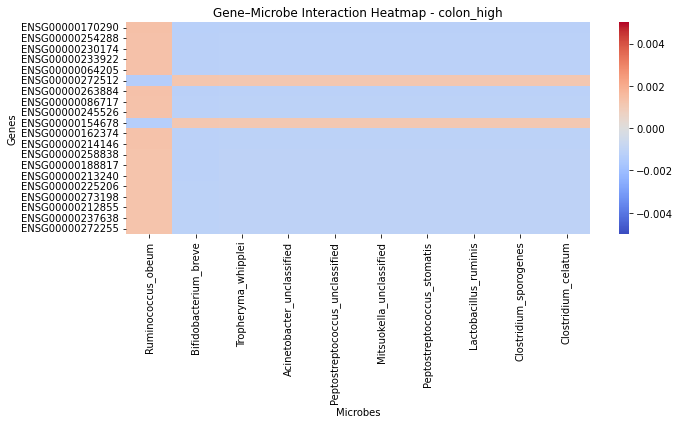

==== colon_low ====
Top Genes: [('ENSG00000101255', 0.021749431541321335), ('ENSG00000273297', 0.019467523041323657), ('ENSG00000236914', 0.01921937943408433), ('ENSG00000182362', 0.01911272441823435), ('ENSG00000272646', 0.01907080482895666), ('ENSG00000165995', 0.019012530403861805), ('ENSG00000108176', 0.018973352825727794), ('ENSG00000197885', 0.018781019883809254), ('ENSG00000162670', 0.01843570603085252), ('ENSG00000121797', 0.018422003758234277), ('ENSG00000183914', -0.018283154720628816), ('ENSG00000152208', -0.01822577343025684), ('ENSG00000103429', 0.01820741718188261), ('ENSG00000105672', 0.01799935689367399), ('ENSG00000155903', 0.017982750207712013), ('ENSG00000139330', 0.017937366837820497), ('ENSG00000128272', 0.017926703686518625), ('ENSG00000253688', 0.017882558794837366), ('ENSG00000113361', 0.017846722755558642), ('ENSG00000187581', -0.01780189253765055)]
Top Microbes: [('Proteus_mirabilis', 0.08078867998599024), ('Odoribacter_laneus', 0.07078345146956859), ('Hafnia_

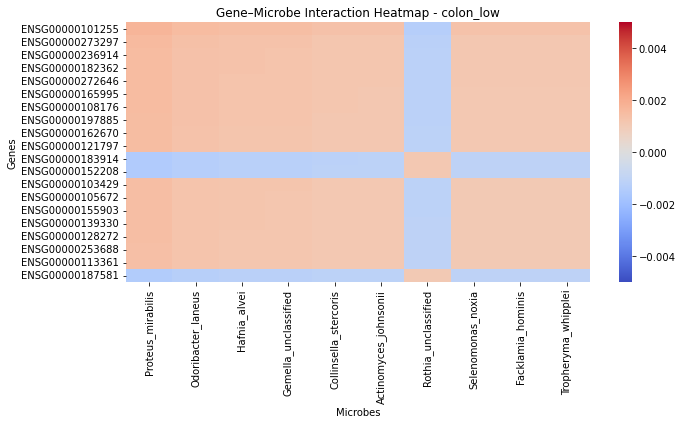

In [10]:
for res in results:
    print(f"==== {res['group']} ====")
    top_genes, top_microbes = get_top_features(res)
    print("Top Genes:", top_genes)
    print("Top Microbes:", top_microbes)

    plot_heatmap(res)

In [11]:
for r in results:
    print(f"Group: {r['group']}")
    print(f"Canonical Correlation 1: {r['corrs'][0]:.3f}")
    print(f"Top Genes ({len(r['genes'])}): {r['genes'][:8]}")
    #print(f"Top Microbes ({len(r['microbes'])}): {r['microbes'][:5]}")
    print("-" * 50)

Group: ileum_high
Canonical Correlation 1: 0.868
Top Genes (4167): ['ENSG00000001036', 'ENSG00000001497', 'ENSG00000001617', 'ENSG00000002586', 'ENSG00000002745', 'ENSG00000002834', 'ENSG00000002933', 'ENSG00000003249']
--------------------------------------------------
Group: ileum_low
Canonical Correlation 1: 0.494
Top Genes (2905): ['ENSG00000000419', 'ENSG00000001036', 'ENSG00000001084', 'ENSG00000002745', 'ENSG00000003393', 'ENSG00000003400', 'ENSG00000003436', 'ENSG00000004059']
--------------------------------------------------
Group: colon_high
Canonical Correlation 1: 0.792
Top Genes (3110): ['ENSG00000002016', 'ENSG00000002745', 'ENSG00000004142', 'ENSG00000004468', 'ENSG00000004799', 'ENSG00000004846', 'ENSG00000004848', 'ENSG00000004948']
--------------------------------------------------
Group: colon_low
Canonical Correlation 1: 0.407
Top Genes (3453): ['ENSG00000000003', 'ENSG00000001561', 'ENSG00000001626', 'ENSG00000001629', 'ENSG00000001630', 'ENSG00000001631', 'ENSG00

Text(0.5, 1.0, 'Canonical Correlation (Component 1)')

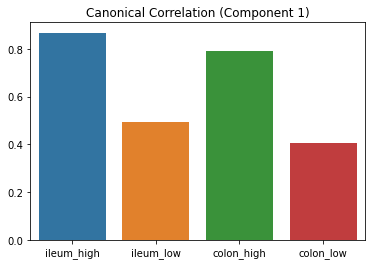

In [12]:
sns.barplot(x=[r["group"] for r in results], y=[r["corrs"][0] for r in results])
plt.title("Canonical Correlation (Component 1)")

Text(0.5, 1.0, 'Canonical Correlation (Component 2)')

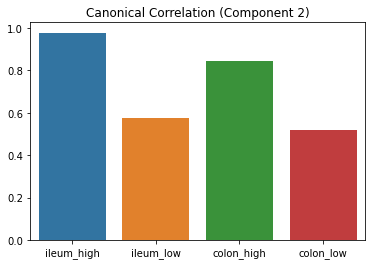

In [13]:
sns.barplot(x=[r["group"] for r in results], y=[r["corrs"][1] for r in results])
plt.title("Canonical Correlation (Component 2)")

import matplotlib.pyplot as plt

plt.scatter(np.dot(U[:, 0], X_np.T), np.dot(V[:, 0], Y_np.T), alpha=0.7, label="Component 1")
plt.scatter(np.dot(U[:, 1], X_np.T), np.dot(V[:, 1], Y_np.T), alpha=0.7, label="Component 2")
plt.xlabel("Canonical Variate for Genes")
plt.ylabel("Canonical Variate for Microbes")
plt.legend()
plt.title("Sparse CCA: Component 1 vs. Component 2")
plt.show()

dontrun

best_corr = 0
best_params = (0.7, 0.9)

for pu in np.linspace(0.5, 1.0, 5):  # Try different penalty values
    for pv in np.linspace(0.5, 1.0, 5):
        U_temp, V_temp, D_temp = pmd(X_np.T @ Y_np, K=2, penaltyu=pu, penaltyv=pv, standardize=False)
        corr_temp = np.corrcoef(np.dot(U_temp[:, 0], X_np.T), np.dot(V_temp[:, 0], Y_np.T))[0, 1]
        
        if corr_temp > best_corr:
            best_corr = corr_temp
            best_params = (pu, pv)

print("Best penalty values:", best_params, "with correlation:", best_corr)

dontrun

best_corr = 0
best_params = (0.7, 0.9)

for pu in np.linspace(0.5, 1.0, 5):  # Try different penalty values
    for pv in np.linspace(0.5, 1.0, 5):
        U_temp, V_temp, D_temp = pmd(X_np.T @ Y_np, K=2, penaltyu=pu, penaltyv=pv, standardize=False)
        corr_temp = np.corrcoef(np.dot(U[:, 1], X_np.T), np.dot(V[:, 1], Y_np.T))[0, 1]
        
        if corr_temp > best_corr:
            best_corr = corr_temp
            best_params = (pu, pv)

print("Best penalty values:", best_params, "with correlation:", best_corr)

# GSEA

In [10]:
import pandas as pd
import gseapy as gp
# Create a dictionary of gene weights
gene_weight_dict = dict(zip(X_scaled.columns, np.abs(U[:, 0])))

# Filter only for selected genes
selected_gene_weights = [gene_weight_dict[gene] for gene in selected_genes]

# Create DataFrame for GSEA ranking
gene_ranking = pd.DataFrame({"GENEID": selected_genes, "score": selected_gene_weights})
gene_ranking = gene_ranking.sort_values(by="score", ascending=False)

In [11]:
gene_ranking

,GENEID,score
2124,ENSG00000131152,0.019156
5097,ENSG00000196866,0.017759
5484,ENSG00000214706,0.017615
2948,ENSG00000147383,0.017216
4879,ENSG00000186395,0.017179
...,...,...
223,ENSG00000053918,0.000008
4117,ENSG00000170927,0.000007
4160,ENSG00000171763,0.000005
2555,ENSG00000138764,0.000003


In [12]:
gene_ranking.to_csv("ranked_genes.rnk", sep="\t", index=False, header=False)

In [13]:
gsea_results = gp.prerank(
    rnk="ranked_genes.rnk",  # Ranked gene file
    gene_sets="KEGG_2019_Human",  # KEGG pathway database
    outdir="GSEA_results",
    permutation_num=1000,
    min_size=5,
    max_size=1000
)

# View results
print(gsea_results.res2d)

2025-03-14 14:24:25,653 [ERROR] No gene sets passed through filtering condition !!! 
Hint 1: Try to lower min_size or increase max_size !
Hint 2: Check gene symbols are identifiable to your gmt input.
Hint 3: Gene symbols curated in Enrichr web services are all upcases.

2025-03-14 14:24:25,653 [ERROR] The first entry of your gene_sets (gmt) look like this : { ABC transporters: [ABCG8, ABCC4, ABCA2, ABCA3, ABCC5, ABCC2, ABCA1, ABCC3, ABCC8, ABCA6, ABCA7, ABCC9, ABCC6, ABCA4, ABCA5, TAP2, TAP1, ABCA8, ABCA9, ABCA10, ABCB10, ABCC10, ABCB11, ABCA12, ABCG1, ABCG4, ABCG5, ABCC1, ABCG2, CFTR, ABCB4, ABCB1, ABCD3, ABCD4, ABCB7, ABCB8, ABCB5, ABCB6, ABCB9, ABCC11, ABCA13, DEFB1, ABCC12, ABCD1, ABCD2]}
2025-03-14 14:24:25,654 [ERROR] The first 5 genes look like this : [ ENSG00000131152, ENSG00000196866, ENSG00000214706, ENSG00000147383, ENSG00000186395 ]


LookupError: No gene sets passed through filtering condition !!! 
Hint 1: Try to lower min_size or increase max_size !
Hint 2: Check gene symbols are identifiable to your gmt input.
Hint 3: Gene symbols curated in Enrichr web services are all upcases.
